In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Figure1: general willingness 
6 figures

In [308]:
# load data for general willingness 

df1_v1p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/1_willingness_final.xlsx')
df1_v2p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/1_willingness_v2.4.xlsx')
df1_v2c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/1_willingness_v3_new.xlsx')

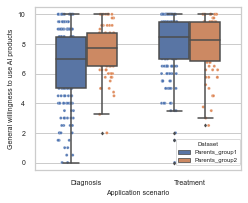

In [318]:
# fig1a willingness box (v1p+v2p), width = 3.7inch


# ---------- Aggregate to subject-level ----------

# df1: subject-level mean per stage
df1_subject = (
    df1_v1p.groupby(["Subject_ID", "Diagnosis_or_Treatment"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "Diagnosis_or_Treatment": "clinical_stage",
           "Response": "response_score"
       })
)
df1_subject["clinical_stage"] = df1_subject["clinical_stage"].map({1: "Diagnosis", 2: "Treatment"})
df1_subject["source"] = "Group 1"

# df2: subject-level mean per stage
df2_subject = (
    df1_v2p.groupby(["Subject_ID", "response_type"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"response_type": "clinical_stage"})
)
df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
stage_order = ["Diagnosis", "Treatment"]
source_order = ["Group 1", "Group 2"]
df_subject["clinical_stage"] = pd.Categorical(df_subject["clinical_stage"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(3.7, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Boxplot
sns.boxplot(
    x="clinical_stage",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    width=0.6,
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2}
)

# Stripplot with subject-level points
sns.stripplot(
    x="clinical_stage",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.9,
    zorder=1
)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(handles[0:2], 
           ["Parents_group1", "Parents_group2"], 
           title="Dataset",
           loc = 'lower right',
           bbox_to_anchor=(1.01, 0.01),
           prop={'size': 6}, 
           title_fontsize=6,
           frameon=True,            # show legend box
           facecolor='white',       # background color
           framealpha=0.7           # semi-transparent
)

# Labels
plt.xlabel("Application scenario")
plt.ylabel("General willingness to use AI products")
#plt.title("Subject-level distributions by clinical stage")

#plt.tight_layout()
plt.savefig("df1_v1p+v2p_boxer_plots.svg", bbox_inches='tight',format="svg")
plt.show()


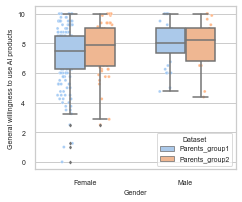

In [320]:
# fig1b gender box plot (v1p+v2p), width = 3.7inch 

# update above figure with data from v2p as well (not sig.), 27-01-26
# fig1b

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- Aggregate to subject-level ----------

# df1: subject-level mean per stage
df1_subject = (
    df1_v1p.groupby(["Subject_ID", "Gender_corr"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "Gender_corr": "Gender",
           "Response": "response_score"
       })
)
#df1_subject["Gender"] = df1_subject["Gender"].map({1: "Diagnosis", 2: "Treatment"})
df1_subject["source"] = "Group 1"

# df2: subject-level mean per stage
df2_subject = (
    df1_v2p.groupby(["Subject_ID", "Gender_corr"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"Gender_corr": "Gender"})
)
#df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
stage_order = ["Female", "Male"]
source_order = ["Group 1", "Group 2"]
df_subject["Gender"] = pd.Categorical(df_subject["Gender"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(3.6, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Boxplot
sns.boxplot(
    x="Gender",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    width=0.6,
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2},
    palette= "pastel"
)

# Stripplot with subject-level points
sns.stripplot(
    x="Gender",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.9,
    zorder=1,
    palette= "pastel"
)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(handles[0:2], 
           ["Parents_group1", "Parents_group2"], 
           title="Dataset",
           loc = 'lower right',
           #bbox_to_anchor=(1.01, 0.01),
           prop={'size': 7}, 
           title_fontsize=7,
           frameon=True,            # show legend box
           facecolor='white',       # background color
           framealpha=0.7           # semi-transparent
)

# Labels
plt.xlabel("Gender")
plt.ylabel("General willingness to use AI products")
#plt.title("Subject-level distributions by clinical stage")

#plt.tight_layout()
plt.savefig("fig1b_df1_v1p+v2p_gender_boxer_plots.svg", bbox_inches='tight', format="svg")
plt.show()


6.814190221518987


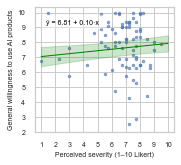

In [333]:
# fig1c v2p severity, width = 2.46


pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/v2p_emm/df1_predictions_severity.csv")


df_avg1 = (
    df1_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 7.48008
slope = 0.09819
x_mean = df_avg1['perceived_severity'].mean()
intercept_new = intercept - (slope * x_mean)
print(intercept_new)

filename = 'fig1c_df1_v2p_severity.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.3))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg1['perceived_severity'], df_avg1['response_score'], alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='green', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='green', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("General willingness to use AI products")
plt.xticks(range(1, 11))
plt.yticks(range(2,11))

formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"

plt.text(
    0.08, 0.9, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.4, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight',format='svg')
plt.show()


6.67191568216


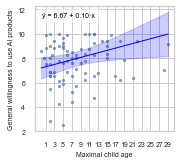

In [341]:
# fig1d v2p max child age, width = 2.46 [⚠️omit same plot for v2p-rep now, since same data]


pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/v2p_emm/df1_max_child_age.csv")

intercept = 7.48008
slope = 0.09928
x_mean = 8.140253
intercept_new = intercept - (slope * x_mean)
print(intercept_new)

filename = 'fig1d_df1_v2p_maximal_child_age_final.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.5, 2.3))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

df_avg_age = (
    df1_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "Max_child_age": "mean",
        "response_score": "mean"
    })
)

plt.scatter(df_avg_age['Max_child_age'], df_avg_age['response_score'], alpha=0.6, s=5)

plt.plot(pred['x_raw'], pred['predicted'], color='blue', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='blue', alpha=0.2)
plt.xlabel("Maximal child age")
plt.ylabel("General willingness to use AI products")
plt.xticks(range(1, 31,2))
plt.yticks(range(2,14,2))

formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"

plt.text(
    0.05, 0.95, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight',format='svg')
plt.show()


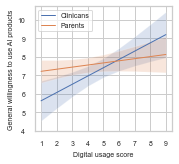

In [348]:
# fig1e v2p_v2c digital usage (interaction), width = 2.46 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load predictions from R ---
pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_v2p_combined_group_analysis/df1_v5_predictions_interaction.csv")

sns.set(style="whitegrid")


# Rename columns if needed
# Should have: 'x', 'predicted', 'conf.low', 'conf.high', 'group'
#print(pred.head())

# --- Create a common x grid for all groups ---
x_common = np.linspace(pred["x_raw"].min(), pred["x_raw"].max(), 100)

aligned_preds = []

# --- Interpolate predictions and CI for each group onto same x-grid ---
for g, df_g in pred.groupby("group"):
    interp_pred = np.interp(x_common, df_g["x_raw"], df_g["predicted"])
    interp_low = np.interp(x_common, df_g["x_raw"], df_g["conf.low"])
    interp_high = np.interp(x_common, df_g["x_raw"], df_g["conf.high"])
    
    aligned_preds.append(
        pd.DataFrame({
            "x_raw": x_common,
            "predicted": interp_pred,
            "conf.low": interp_low,
            "conf.high": interp_high,
            "group": g
        })
    )

pred_aligned = pd.concat(aligned_preds, ignore_index=True)

# --- Plot with aligned CIs ---
sns.set(style="whitegrid")
plt.figure(figsize=(2.5, 2.3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})


for g, df_g in pred_aligned.groupby("group"):
    plt.plot(df_g["x_raw"], df_g["predicted"], label=g, linewidth=1)
    plt.fill_between(df_g["x_raw"], df_g["conf.low"], df_g["conf.high"], alpha=0.2)

plt.xlabel("Digital usage score")
plt.ylabel("General willingness to use AI products")
plt.xticks(range(1, 10))
plt.yticks(range(4,11))


handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], 
           ["Clinicans", "Parents"], 
           #title="Dataset",
           loc = 'upper left',
           #bbox_to_anchor=(1.01, 0.01),
           prop={'size': 7}, 
           title_fontsize=7,
           frameon=True,            # show legend box
           facecolor='white',       # background color
           framealpha=0.7           # semi-transparent
)


plt.tight_layout()  # leave room on right for legend

plt.savefig('fig1e_df1_v5_interaction.svg', bbox_inches='tight')
plt.show()


### Figure2: accuracy results

In [56]:
# load data of all df2 

df2_v1p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/2_accuracy_final.xlsx')
df2_v2p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/2_accuracy_v2.4.xlsx')
df2_v2c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/2_accuracy_v3_new.xlsx')

In [58]:
df2_v1p.columns

Index(['Unnamed: 0', 'Subject_ID', 'Age', 'Number_of_children',
       'Mean_age_children', 'Max_child_age', 'City_scale',
       'Family_income_ordinal', 'Previous_AI_knowledge_score',
       'Digital_usage_score', 'Response', 'Worse0_equal1_better2',
       'Education_level_new', 'Gender_corr', 'Diagnosis_or_Treatment',
       'Response_new', 'Story_ID', 'Years_of_education'],
      dtype='object')

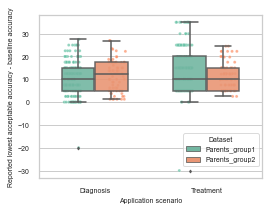

In [323]:
# fig2a, width = 4inch

# ---------- Aggregate to subject-level ----------

# df1: subject-level mean per stage
df1_subject = (
    df2_v1p.groupby(["Subject_ID", "Diagnosis_or_Treatment"], as_index=False)["Response"]
       .mean()
       .rename(columns={
           "Diagnosis_or_Treatment": "clinical_stage",
           "Response": "response_score"
       })
)

df1_subject["clinical_stage"] = df1_subject["clinical_stage"].str.strip().str.capitalize()
#print(df1_subject['clinical_stage'])
df1_subject["source"] = "Group 1"

# df2: subject-level mean per stage
df2_subject = (
    df2_v2p.groupby(["Subject_ID", "response_type"], as_index=False)["response_score"]
       .mean()
       .rename(columns={"response_type": "clinical_stage"})
)
df2_subject["clinical_stage"] = df2_subject["clinical_stage"].str.strip().str.capitalize()
df2_subject["source"] = "Group 2"

# Merge
df_subject = pd.concat([df1_subject, df2_subject], ignore_index=True)

# Ensure categorical ordering
stage_order = ["Diagnosis", "Treatment"]
source_order = ["Group 1", "Group 2"]
df_subject["clinical_stage"] = pd.Categorical(df_subject["clinical_stage"], categories=stage_order, ordered=True)
df_subject["source"] = pd.Categorical(df_subject["source"], categories=source_order, ordered=True)

# ---------- Plot ----------
sns.set(style="whitegrid")
plt.figure(figsize=(4, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Add a dashed line at zero so the negative values are meaningful
#plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=1)

# Boxplot
sns.boxplot(
    x="clinical_stage",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    width=0.6,
    dodge=True,
    whis=1.5,
    fliersize=2,
    boxprops={'zorder': 2, 'alpha': 0.9},
    palette="Set2"
)

# Stripplot with subject-level points
sns.stripplot(
    x="clinical_stage",
    y="response_score",
    hue="source",
    data=df_subject,
    order=stage_order,
    hue_order=source_order,
    dodge=True,
    jitter=0.15,
    size=3,
    edgecolor="w",
    linewidth=0.25,
    alpha=0.7,
    zorder=1,
    palette="Set2"
)

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], 
           ["Parents_group1", "Parents_group2"], 
           title="Dataset",
           loc = 'lower right',
           bbox_to_anchor=(1.0, 0.05),
           prop={'size': 7}, 
           title_fontsize=7,
           frameon=True,            # show legend box
           facecolor='white',       # background color
           framealpha=0.7           # semi-transparent
)

# Labels
plt.xlabel("Application scenario")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
#plt.title("Subject-level distributions by clinical stage")

#plt.tight_layout()
plt.savefig("fig2a_df2_v1p+v2p_boxer_plots.svg", bbox_inches='tight', format="svg")
plt.show()

7.2527906329113945
7.097046413502108


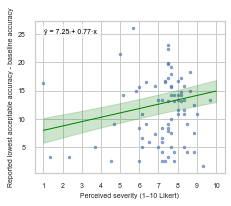

In [102]:
# fig2b, v2p severity, width = 3.4 inch 

pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/v2p_emm/df2_predictions_severity.csv")


df_avg2 = (
    df2_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 12.72802
slope = 0.77148

x_mean = df_avg2['perceived_severity'].mean()
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
print(x_mean)

filename = 'fig2b_df2_v2p_new_severity.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(3.4, 2.8))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg2['perceived_severity'], df_avg2['response_score'], alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='green', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='green', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
plt.xticks(range(1, 11))

formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"

plt.text(
    0.05, 0.95, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, format='svg')
plt.show()


7.6565656565656575


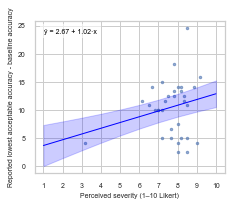

In [105]:
# fig2c, v2c severity accuracy 

pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_sig_emm/df2_predictions_severity_v2c_new.csv")
#df_raw = pd.read_csv("your_raw_data.csv")

df_avg = (
    df2_v2c.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 10.480720
slope = 1.024460
x_mean = df_avg['perceived_severity'].mean()
print(x_mean)
filename = 'fig2c_v2c_severity_new.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(3.4, 2.8)) #need to change to 3.5, 4
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg['perceived_severity'], df_avg['response_score'], alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='blue', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='blue', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
plt.xticks(range(1, 11))

#intercept_new = intercept - (slope * x_mean)
#print(intercept_new)
intercept_new = 2.67037

formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"

plt.text(
    0.05, 0.95, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, format='svg')
plt.show()


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:30: FutureWarning: Passing `palette` without assigning `hue` is deprecated.


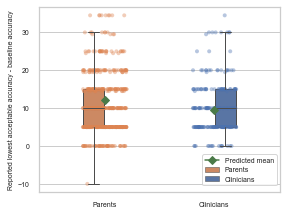

In [143]:
# fig2d, v2p+v2c differences 

df = pd.read_excel("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/combined_v5_finalver_v2p+v2c/2_combined_data_accuracy_v5.xlsx")
pred = pd.read_csv("df2_v5_group.csv")

# --- Plot setup ---
sns.set(style="whitegrid")
plt.figure(figsize=(4, 3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Define a color palette for groups
palette = sns.color_palette("deep", n_colors=df["group"].nunique())[::-1]

# --- Layer 1: Raw data (jittered points) ---
sns.stripplot(
    data=df,
    x="group", y="response_score",
    color="gray", palette=palette, 
    alpha=0.4, size=4,
    jitter=0.2, dodge=False, zorder=1,
    legend=False
)

#target_order = ['Clinicians', 'Parents']

# --- Layer 2: Boxplot (group summary) ---
sns.boxplot(
    data=df, x="group", y="response_score",
    palette=palette, hue='group',
    width=0.4, color="lightgray",
    showfliers=False, zorder=2,
    linewidth=1
)

# --- Layer 3: Model-predicted means + 95% CI ---


if 'pred' in globals():
    for i, row in pred.iterrows():
        # Plot diamond marker
        plt.plot(row["x"], row["predicted"], 
                marker="D", markersize=5, 
                color="#4a7a48", zorder=10,
                label="Predicted mean" if i == 0 else "")
    
    # Simple legend with only predicted mean
    plt.legend(bbox_to_anchor=(1, 0.02), loc='lower right', fontsize=7,frameon=True)


# --- Labels and layout ---

plt.ylabel("Reported lowest acceptable accuracy - baseline accuracy")
plt.xlabel("")
#plt.title("Raw data, group distributions, and model-adjusted means", fontsize=11)
plt.tight_layout()
plt.savefig('fig2d_df2_v5_group_effects.svg',bbox_inches='tight')
plt.show()


### Figure3: maximal error results
3 figures

In [144]:
df3_v1p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/3_error-rate_final.xlsx')

df3_v2p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/3_error_rate_v2.4.xlsx')

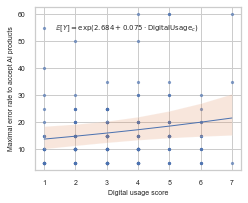

In [152]:
# fig3a, width 3.7 inch 

# -----------------------------
# Load predicted values
# -----------------------------
pred = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/df3_v1p_digital.csv")


df_avg3 = (
    df3_v1p.groupby("Subject_ID", as_index=False)
    .agg({
        "Digital_usage_score": "mean",
        "Response": "mean"
    })
)

# -----------------------------
# Observed data
# -----------------------------
x_obs = df_avg3["Digital_usage_score"].values   # original scale
y_obs = df_avg3["Response"].values

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(3.7,3))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Observed data points
plt.scatter(
    x_obs, y_obs,
    alpha=0.6,
    s=5,
    label="Observed data"
)

# Fitted exponential curve
plt.plot(
    pred["Digital_usage_score"],
    pred["fit"],
    linewidth=1,
    label="Fitted effect"
)

# Confidence band
plt.fill_between(
    pred["Digital_usage_score"],
    pred["lwr"],
    pred["upr"],
    alpha=0.2,
    label="95% CI"
)

# Labels and title
plt.xlabel("Digital usage score")
plt.ylabel("Maximal error rate to accept AI products")
#plt.title("Effect of Digital Usage Score on Response")

# -----------------------------
# Formula annotation
# -----------------------------
formula = (
    r"$\mathbb{E}[Y] = \exp(2.684 + 0.075 \cdot \mathrm{DigitalUsage}_c)$"
)

plt.text(
    0.1, 0.9,
    formula,
    transform=plt.gca().transAxes,
    fontsize=7,
    verticalalignment="top"
)

#plt.legend()
filename = 'fig3a_df3_v1p_digital_new.svg'
plt.savefig(filename, format='svg')
plt.show()


25.826885804359996


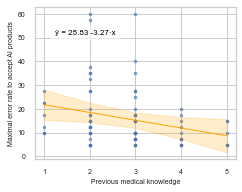

In [161]:
# fig3b, v2p medical_knowledge & error

# new severity plot & accuracy 2025-11-04 (v2p_new = 79)

pred = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/0_v2p_n=79_makefigs/df3_medical_knowledge.csv")
#df_raw = pd.read_csv("your_raw_data.csv")

df_avg3 = (
    df3_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "Previous_medical_knowledge": "mean",
        "response_score": "mean"
    })
)

intercept = 16.68960
slope = -3.26627
x_mean = 2.797468
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
filename = 'fig3b_df3_v2p_new_medical_error-rate.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(3.6, 2.8))
    
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

#plt.scatter(df_avg['Previous_medical_knowledge'], df_avg['response_score'], alpha=0.6, s=25)
plt.scatter(
    df_avg3['Previous_medical_knowledge'],
    df_avg3['response_score'],
    alpha=0.6, s=6
)


plt.plot(pred['x_raw'], pred['predicted'], color='orange', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='orange', alpha=0.2)
plt.xlabel("Previous medical knowledge")
plt.ylabel("Maximal error rate to accept AI products")
plt.xticks(range(1, 6))

formula_text = f"ŷ = {intercept_new:.2f} {slope:.2f}·x"

plt.text(
    0.1, 0.85, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=8, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, format='svg',bbox_inches='tight')
plt.show()


In [162]:
df3_v2p.columns

Index(['Subject_ID', 'Age', 'Gender_corr', 'Number_of_children',
       'Max_child_age', 'If_adult_child', 'Mean_age_children',
       'Education_level', 'Family_income_ordinal',
       'Previous_AI_knowledge_score', 'Digital_usage_score',
       'Previous_medical_knowledge', 'disease', 'experience',
       'perceived_severity', 'response_type', 'response_score',
       'Years_of_education'],
      dtype='object')

In [164]:
# fig3c, v2p-rep & years_of_education, width = 5 

pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_replicate_v1p/v2p_rep_new_results/sig_emm/df3_v2p_rep_edu.csv")

df_avg = (
    df3_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "Years_of_education": "mean",
        "response_score": "mean"
    })
)

In [166]:
df_avg

,Subject_ID,Years_of_education,response_score
0,18,12.0,57.5
1,20,15.0,5.0
2,22,17.0,15.0
3,24,12.0,40.0
4,26,17.0,15.0
...,...,...,...
74,126,12.0,7.5
75,130,10.0,5.0
76,131,17.0,5.0
77,133,NaN,15.0


In [167]:
pred

,x,predicted,std.error,conf.low,conf.high,group,x_raw
0,-5.576923,23.221370,3.685562,15.935265,30.507474,1,10
1,-4.576923,21.841959,3.162889,15.589144,28.094774,1,11
2,-3.576923,20.462548,2.673886,15.176459,25.748637,1,12
3,-2.576923,19.083137,2.240707,14.653413,23.512861,1,13
4,-1.576923,17.703726,1.901887,13.943826,21.463625,1,14
5,-0.576923,16.324315,1.714316,12.935229,19.713401,1,15
6,0.423077,14.944904,1.727973,11.528819,18.360988,1,16
7,1.423077,13.565493,1.938609,9.732995,17.397990,1,17
8,2.423077,12.186082,2.292558,7.653852,16.718312,1,18
9,3.423077,10.806671,2.734729,5.400299,16.213042,1,19


36.98240769230769
15.576923076923077


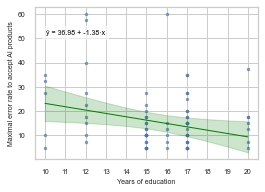

In [173]:
# fig4b, v2p & severity on privacy willingness


intercept = 15.4956
slope = -1.3794

x_mean = df_avg['Years_of_education'].mean()
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
print(x_mean)

filename = 'fig3c_v2p-rep_edu.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(4, 2.8))
    

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg['Years_of_education'], df_avg['response_score'], alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='green', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='green', alpha=0.2)
plt.xlabel("Years of education")
plt.ylabel("Maximal error rate to accept AI products")
plt.xticks(range(10, 21))

formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"

plt.text(
    0.05, 0.85, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight', format='svg')
plt.show()

### Figure4: privacy results

In [174]:
# load data of all df4 

df4_v1p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/4_privacy_final_corr.xlsx')
df4_v2p = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/4_privacy_v2.4.xlsx')
df4_v2c = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/4_df4_v2c_final.xlsx')

In [7]:
df4_avg_v1p = pd.DataFrame(df4_v1p.groupby(['Subject_ID', 'privacy_level','Gender_corr'])['response_score'].mean()).reset_index()

In [8]:
df4_avg_v2p = pd.DataFrame(df4_v2p.groupby(['Subject_ID', 'privacy_level','Gender_corr'])['response_score'].mean()).reset_index()

In [10]:
df4_avg_v2c = pd.DataFrame(df4_v2c.groupby(['Subject_ID', 'privacy_level','Gender_corr'])['response_score'].mean()).reset_index()

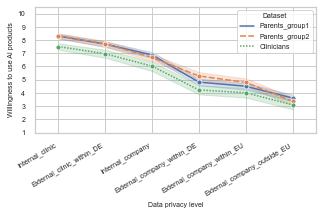

In [54]:
# fig4a, v1p+v2p+v2c line plots, width = 4.9 inch


# 1. Combine dataframes and add a 'Group' identifier
# Replace df_p1, df_p2, and df_cl with your actual variable names
df4_v1p['Group'] = 'Parents_group1'
df4_v2p['Group'] = 'Parents_group2'
df4_v2c['Group'] = 'Clinicians'

# Concatenate them into one master dataframe for plotting
df_combined = pd.concat([df4_v1p, df4_v2p, df4_v2c], ignore_index=True)

# 2. Setup the Plotting Style
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.figure(figsize=(4.5, 3))

# 3. Generate the Lineplot
# 'hue' creates the three separate lines based on the 'Group' column
sns.lineplot(
    x='privacy_level', 
    y='response_score', 
    hue='Group', 
    style='Group', # Different line styles (optional)
    errorbar='ci', 
    data=df_combined, 
    marker="o",
    markersize=5
)

# 4. Axis and Label Formatting
plt.xlabel("Data privacy level")
plt.ylabel("Willingness to use AI products")

custom_xticks = [
    "Internal_clinic", "External_clinic_within_DE", "Internal_company",
    "External_company_within_DE", "External_company_within_EU", "External_company_outside_EU"
]

# Ensure privacy_level is treated as the correct numeric index for xticks
plt.xticks(ticks=range(1, len(custom_xticks) + 1), labels=custom_xticks, rotation=30, ha='right')
plt.xlim(0.5, len(custom_xticks) + 0.5)
plt.yticks(range(1, 11))
plt.ylim(1, 10.5)

# Move legend to a clear spot
plt.legend(title="Dataset", loc='upper right', prop={'size': 7},      
                  title_fontsize=7)

plt.tight_layout()
plt.savefig("df4a_privacy_allgroups.svg", format='svg')
plt.show()

5.382128101265823
6.781645569620253


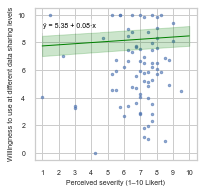

In [179]:
# fig4b, v2p & severity on privacy willingness

pred = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/v2p_emm/df4_predictions_severity_final.csv")
#df_raw = pd.read_csv("your_raw_data.csv")

df_avg = (
    df4_v2p.groupby("Subject_ID", as_index=False)
    .agg({
        "perceived_severity": "mean",
        "response_score": "mean"
    })
)

intercept = 5.929
slope = 0.08064

x_mean = df_avg['perceived_severity'].mean() #6.781646
intercept_new = intercept - (slope * x_mean)
print(intercept_new)
print(x_mean)

filename = 'fig4b_df4_v2p_severity.svg'

sns.set(style="whitegrid")

plt.figure(figsize=(2.9, 2.8))
    

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

plt.scatter(df_avg['perceived_severity'], df_avg['response_score'], alpha=0.6, s=6)

plt.plot(pred['x_raw'], pred['predicted'], color='green', linewidth=1)
plt.fill_between(pred['x_raw'], pred['conf.low'], pred['conf.high'], color='green', alpha=0.2)
plt.xlabel("Perceived severity (1–10 Likert)")
plt.ylabel("Willingness to use at different data sharing levels")
plt.xticks(range(1, 11))

formula_text = f"ŷ = {intercept_new:.2f} + {slope:.2f}·x"

plt.text(
    0.05, 0.9, formula_text,
    transform=plt.gca().transAxes,  # relative position
    fontsize=7, color="black",
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.3, edgecolor="none")
)
    
plt.savefig(filename, bbox_inches='tight', format='svg')
plt.show()

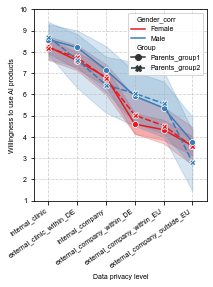

In [14]:
# fig4c, gender plots for two parents group 

# Add a label to each dataset before merging
df4_avg_v1p['Group'] = 'Parents_group1'
df4_avg_v2p['Group'] = 'Parents_group2'

# Combine them
df_combined = pd.concat([df4_avg_v1p, df4_avg_v2p])

plt.figure(figsize=(3, 4))

plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# hue='Gender_corr' keeps colors for Male/Female
# style='Group' gives different line styles for Parents/Clinicians
sns.lineplot(x='privacy_level', y='response_score', errorbar='ci', 
             hue='Gender_corr', style='Group', markers=True, dashes=True,
             data=df_combined, palette='Set1', markersize=6)

plt.xlabel("Data privacy level")
plt.ylabel("Willingness to use AI products")
#plt.title("Willingness by Privacy Level: Parents vs. Clinicians")

# Adjusting the legend to show both Gender and Group clearly
#plt.legend(title="Gender & Group", loc='upper left', bbox_to_anchor=(1, 1))

custom_xticks = ["internal_clinic","external_clinic_within_DE",'internal_company',
                 'external_company_within_DE','external_company_within_EU','external_company_outside_EU']

plt.xticks(ticks=range(1, len(custom_xticks) + 1), labels=custom_xticks, rotation=35, ha='right')
plt.xlim(0.5, len(custom_xticks)+0.5)
plt.yticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("fig4c_v1p+v2p_gender_privacy.svg", format='svg')
plt.show()

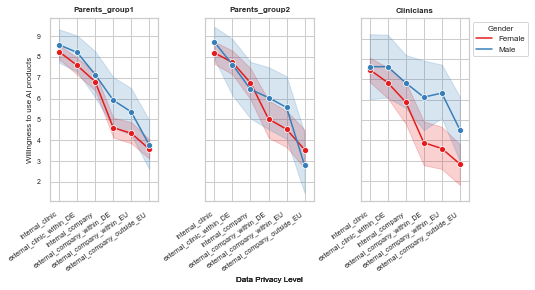

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Setup global style
sns.set(style="whitegrid")
plt.rcParams.update({
    'font.size': 7, 'font.family': 'Arial',
    'axes.titlesize': 8, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7
})

# 2. Define labels
custom_xticks = ["internal_clinic", "external_clinic_within_DE", "internal_company",
                 "external_company_within_DE", "external_company_within_EU", "external_company_outside_EU"]

# 3. Create the figure with 2 subplots (1 row, 2 columns)
# sharey=True is critical to compare the "height" of willingness between groups
fig, axes = plt.subplots(1, 3, figsize=(7.4, 4), sharey=True)

# Define your dataframes and their titles
data_list = [df4_avg_v1p, df4_avg_v2p, df4_avg_v2c] 
titles = ["Parents_group1", "Parents_group2", "Clinicians"]

target_order = ['Female', 'Male']

for i, ax in enumerate(axes):
    # Plotting
    sns.lineplot(x='privacy_level', y='response_score', hue='Gender_corr', hue_order=target_order,
                 data=data_list[i], marker="o", markersize=6, palette='Set1', 
                 errorbar='ci', ax=ax)
    
    # Formatting
    ax.set_title(titles[i], fontweight='bold')
    ax.set_xlabel("")
    ax.set_xticks(range(1, len(custom_xticks) + 1))
    ax.set_xticklabels(custom_xticks, rotation=35, ha='right')
    ax.set_xlim(0.5, len(custom_xticks) + 0.5)
    ax.set_yticks(range(1, 11))
    
    fig.text(0.5, 0.02, 'Data Privacy Level', ha='center', fontsize=8)
    
    if i == 0 or i == 1:
        ax.set_ylabel("Willingness to use AI products")
        ax.get_legend().remove() # Remove legend from first plot
    else:
        ax.set_ylabel("") # Hide Y-label for the second plot
        # Place legend outside the second plot
        ax.legend(title="Gender", loc='upper left', 
                  bbox_to_anchor=(1, 1),prop={'size': 8},      
                  title_fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.savefig("fig_privacy_comparison_subplots.svg", format='svg', bbox_inches='tight')
plt.show()

### Figure5: decision plots
6 figures

In [221]:
# load data for figure5

df1 = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/data_v1p_final/5_decision_final.xlsx')
df2 = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2p_data/5_decision_v2.4.xlsx')
df3 = pd.read_excel('/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_data/5_decision_v3_new.xlsx')


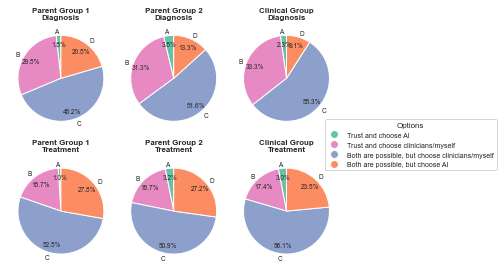

In [240]:
# fig5a (width=4.5 inch) / 7.3 inch


# 1. Standardize and Combine
# Use 'response' as the universal column name for all 3 groups
df1_plot = df1.rename(columns={
    'Response': 'response', 
    'Diagnosis_or_Treatment': 'response_type'
}).copy()

df1_plot["group"] = "Parent Group 1"
df1_plot["clinical_stage"] = df1_plot["response_type"].str.strip().str.capitalize()

df2_plot = df2.rename(columns={'response_score': 'response'}).copy() # Ensure df2 uses 'response'
df2_plot["group"] = "Parent Group 2"
df2_plot["clinical_stage"] = df2_plot["response_type"].str.strip().str.capitalize()

df3_plot = df3.rename(columns={'response_score': 'response'}).copy() # Ensure df3 uses 'response'
df3_plot["group"] = "Clinical Group"
df3_plot["clinical_stage"] = df3_plot["response_type"].str.strip().str.capitalize()

df_plot = pd.concat([df1_plot, df2_plot, df3_plot], ignore_index=True)

# 2. Define Color Mapping (Keys must match the values in the 'response' column)
color_map = {
    "A": "#66c2a5", "B": "#e78ac3", "C": "#8da0cb", "D": "#fc8d62"
}


# 4. Plotting Grid
stages = ["Diagnosis", "Treatment"]
groups = ["Parent Group 1", "Parent Group 2", "Clinical Group"]

plt.rcParams.update({
    'font.size': 7, 'font.family': 'Arial',
    'axes.titlesize': 8, 'axes.labelsize': 8,
    'xtick.labelsize': 7, 'ytick.labelsize': 7
})

count_data = (
    df_plot.groupby(["group", "clinical_stage", "response"])
    .size()
    .reset_index(name="count")
)

fig, axes = plt.subplots(len(stages), len(groups), figsize=(7.4, 4.5))

for i, stage in enumerate(stages):
    for j, grp in enumerate(groups):
        ax = axes[i, j]
        
        subset = count_data[(count_data["clinical_stage"] == stage) & (count_data["group"] == grp)]
        #n_val = n_sizes[(n_sizes["clinical_stage"] == stage) & (n_sizes["group"] == grp)]["total_n"].values
        #current_n = n_val[0] if len(n_val) > 0 else 0
        
        if not subset.empty:
            # Crucial: Use 'response' here to match color_map keys
            subset = subset.sort_values("response")
            current_colors = [color_map[res] for res in subset["response"]]
            
            ax.pie(
                subset["count"],
                labels=subset["response"],
                autopct="%1.1f%%",
                startangle=90,
                colors=current_colors,
                pctdistance=0.80,
                textprops={'fontsize': 6.5}
            )
            
        
        ax.set_title(f"{grp}\n{stage}", fontsize=8, fontweight='bold')

# 5. Legend and Output

# Create a mapping for descriptive labels
label_map = {
    "A": "Trust and choose AI",
    "B": "Trust and choose clinicians/myself",
    "C": "Both are possible, but choose clinicians/myself",
    "D": "Both are possible, but choose AI"
}

# Update the legend generator
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', 
               label=label_map[k], # Use the map here
               markerfacecolor=v, markersize=8) 
    for k, v in color_map.items()
]

#legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f"{k}",
#                              markerfacecolor=v, markersize=10) for k, v in color_map.items()]

fig.legend(handles=legend_elements, title="Options", loc="center right", 
           bbox_to_anchor=(1.05, 0.5), title_fontsize=8, fontsize=7, frameon=True)

#plt.suptitle("Comparative Choice Distribution Across All Groups", fontsize=14, y=0.98)
#plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.subplots_adjust(
    right=0.75,  # Leaves room for your legend on the right
    top=0.9,
    bottom=0.1,
    wspace=0.05, # Very small horizontal gap
    hspace=0.05   # Small vertical gap
)

plt.savefig('fig5a_df5_pie_chart_allgroups.svg', format='svg', bbox_inches='tight')
plt.show()

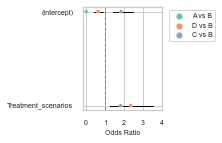

In [301]:
# fig5b (width=2.9 inch)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v1p_R/df5_v1p_significant_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "A vs B"
    elif term.startswith("muC_"):
        return "C vs B"
    elif term.startswith("muD_"):
        return "D vs B"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "Diagnosis_or_Treatmenttreatment": "Treatment_scenarios",
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(2.4, 2))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(1.05, 1),fontsize=7, markerscale=0.85)

plt.tight_layout()
plt.savefig('fig5b_df5_v1p.svg', bbox_inches='tight',format='svg')
plt.show()


No handles with labels found to put in legend.


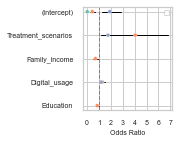

In [298]:
# fig5c (width=3.4 inch)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/AI-PHCA_v2_analysis_202507/scripts/df5_v2p_rep_sig_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "A vs B"
    elif term.startswith("muC_"):
        return "C vs B"
    elif term.startswith("muD_"):
        return "D vs B"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "response_typetreatment": "Treatment_scenarios",
    "Digital_usage_score_c": "Digital_usage",
    "Family_income_ordinal_c": "Family_income",
    "Years_of_education_c": "Education"
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(2.5, 2))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3,
    legend=False
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4,5,6,7])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(1, 1),prop={'size': 6},      
                  title_fontsize=7)

plt.tight_layout()
plt.savefig('df5_v2p_rep.svg', format='svg', bbox_inches='tight')
plt.show()


No handles with labels found to put in legend.


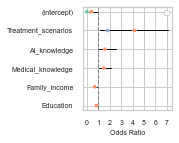

In [297]:
# fig3d, v2p all 2.5 inch (2.8 inch)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2p_all_predictors/df5_v2p_sig_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "A vs B"
    elif term.startswith("muC_"):
        return "C vs B"
    elif term.startswith("muD_"):
        return "D vs B"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "response_typetreatment": "Treatment_scenarios",
    "Family_income_ordinal_c": "Family_income",
    "Years_of_education_c": "Education",
    "Previous_medical_knowledge_c": "Medical_knowledge",
    "Previous_AI_knowledge_score_c":"AI_knowledge"
    
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(2.5, 2))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3,
    legend=False
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4,5,6,7])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(1, 1),prop={'size': 6},      
                  title_fontsize=7)

plt.tight_layout()
plt.savefig('fig5d_df5_v2p.svg', format='svg', bbox_inches='tight')
plt.show()


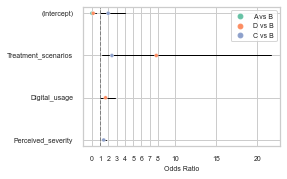

In [305]:
# fig5e, v2c, width = 4 (legend out)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_R/v2c_sig_emm/df5_v2c_sig_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "A vs B"
    elif term.startswith("muC_"):
        return "C vs B"
    elif term.startswith("muD_"):
        return "D vs B"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "response_typetreatment": "Treatment_scenarios",
    "Digital_usage_score_c": "Digital_usage",
    "perceived_severity_c": "Perceived_severity"
    
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(4, 2.5))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4,5,6,7,8,10,15,20])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(1, 1),prop={'size': 7}, markerscale=0.8,     
                  title_fontsize=7)

plt.tight_layout()
plt.savefig('fig5e_df5_v2c.svg', format='svg', bbox_inches='tight')
plt.show()


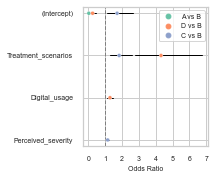

In [307]:
# fig5f, v2c_v2p, width = 3.4 

# fig5e, v2c, width = 4 (legend out)

# Load significant coefficients
sig_coefs = pd.read_csv("/Users/carriesmac/Desktop/Results_in_excel待写/v2c_v2p_combined_group_analysis/df5_v2p+v2c_significant_fixed_effects.csv")


# --- Extract comparison and predictor from term ---
def get_category(term):
    if term.startswith("muA_"):
        return "A vs B"
    elif term.startswith("muC_"):
        return "C vs B"
    elif term.startswith("muD_"):
        return "D vs B"
    else:
        return None

sig_coefs["category"] = sig_coefs["term"].apply(get_category)
sig_coefs["predictor"] = sig_coefs["term"].apply(lambda x: x.split("_", 1)[1])

# Create the mapping
rename_dict = {
    "response_typetreatment": "Treatment_scenarios",
    "Digital_usage_score_c": "Digital_usage",
    "perceived_severity_c": "Perceived_severity"
    
}

# Apply it to the column
sig_coefs["predictor"] = sig_coefs["predictor"].map(rename_dict).fillna(sig_coefs["predictor"])

# --- Convert log-odds to odds ratios ---
sig_coefs["odds_ratio"] = np.exp(sig_coefs["estimate"])
sig_coefs["ci_low_or"] = np.exp(sig_coefs["conf.low"])
sig_coefs["ci_high_or"] = np.exp(sig_coefs["conf.high"])

# --- Sort by effect size (odds ratio) ---
#sig_coefs = sig_coefs.sort_values(by="odds_ratio")

# Rank predictors by effect size (distance from OR=1), from high to low
sig_coefs["effect_size"] = np.abs(np.log(sig_coefs["odds_ratio"]))
sig_coefs = sig_coefs.sort_values(by="effect_size", ascending=False)

# --- Plot ---
plt.figure(figsize=(3, 2.5))
sns.set(style="whitegrid")


plt.rcParams.update({
    'font.size': 7,
    'font.family': 'Arial',
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

# Scatterplot of odds ratios
sns.scatterplot(
    data=sig_coefs,
    x="odds_ratio",
    y="predictor",
    hue="category",
    s=15,
    palette="Set2",
    zorder=3
)

# Add CI error bars
for i, row in sig_coefs.iterrows():
    plt.plot(
        [row["ci_low_or"], row["ci_high_or"]],
        [row["predictor"], row["predictor"]],
        color="black",
        linewidth=1,
        zorder=2
    )

# Reference line at OR = 1 (no effect)
plt.axvline(1, color="grey", linestyle="--", linewidth=1)

# Labels
#plt.xscale('log')
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.xlabel("Odds Ratio")
plt.xticks([0,1,2,3,4,5,6,7])
#plt.title("Significant Fixed Effects (A/C/D vs B)")
plt.legend(bbox_to_anchor=(1, 1),prop={'size': 7}, markerscale=0.8,     
                  title_fontsize=7)

plt.tight_layout()
plt.savefig('fig5f_df5_v2c-v2p.svg', format='svg', bbox_inches='tight')
plt.show()


### Table S1 
- correlation between pairs of DVs
- df4 is averaged score across privacy levels

In [2]:
# load datasets 

my_files = {
    'v1p': 'v1p_data.xlsx',  #⚠️raw csv before preprocessing 
    'v2p':  'v2p_data.xlsx',
    'v2c':  'v2c_data.xlsx'
}

# Define your pairs
my_pairs1 = [('DV1', 'DV2'), ('DV1', 'DV4')]

my_pairs2 = [('DV2', 'DV3'),('DV1', 'DV3')]

In [8]:
def transform_research_data(file_path, output_path=None):
    # 1. Load your wide dataframe
    df_wide = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
    
    # 2. Identify the 'stub' names
    # These are the prefixes of your columns before the underscore (e.g., DV1, DV2, DV3, DV4)
    # Adjust this list based on exactly which DVs you have
    dv_stubs = ['DV1', 'DV2', 'DV4']
    
    # 3. Perform the transformation
    # j='Scenario' creates a new column for the number after the underscore
    df_long = pd.wide_to_long(
        df_wide, 
        stubnames=dv_stubs, 
        i=['Subject_ID'], # This is your unique participant ID
        j='Scenario', 
        sep='_', 
        suffix='\\d+' # Tells pandas to look for numbers (1, 2, 3, 4)
    ).reset_index()

    # 4. Optional: Map Scenario numbers to names
    scenario_map = {1: 'pneumonia', 2: 'asthma', 3: 'developmentaldelay', 4: 'cancer'}
    df_long['Scenario_Name'] = df_long['Scenario'].map(scenario_map)

    if output_path:
        df_long.to_csv(output_path, index=False)
        print(f"Long-format data saved to {output_path}")

    return df_long

# --- Usage ---
# df_long = transform_research_data('my_wide_data.csv', 'my_long_data.csv')

In [14]:
df_long_v1p = transform_research_data('v1p_data.xlsx', 'v1p_long.xlsx')

Long-format data saved to v1p_long.xlsx


In [17]:
def transform_research_data_v2(file_path, output_path=None):
    # 1. Load your wide dataframe
    df_wide = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
    
    # 2. Identify the 'stub' names
    # Including DV3 in the stubs so it's captured for stories 6 & 8
    dv_stubs = ['DV1', 'DV2', 'DV4']
    
    # 3. Perform the transformation to Long Format
    df_long = pd.wide_to_long(
        df_wide, 
        stubnames=dv_stubs, 
        i=['Subject_ID'], 
        j='Story', 
        sep='_', 
        suffix='\\d+' 
    ).reset_index()

    # 4. Encode Stories (1-8) into Disease Categories
    # Logic: 1,2 -> pneumonia; 3,4 -> asthma; 5,6 -> cancer; 7,8 -> developmental delay
    disease_map = {
        1: 'pneumonia', 2: 'pneumonia',
        3: 'asthma', 4: 'asthma',
        5: 'cancer', 6: 'cancer',
        7: 'developmentaldelay', 8: 'developmentaldelay'
    }
    df_long['Disease'] = df_long['Story'].map(disease_map)

    # 5. Average DVs across the two stories per disease for each subject
    # This collapses the 8 stories into 4 diseases per subject
    # IMPORTANT: .mean() treats 0 as a value and NaN as missing
    df_disease_avg = df_long.groupby(['Subject_ID', 'Disease'])[dv_stubs].mean().reset_index()

    if output_path:
        df_disease_avg.to_csv(output_path, index=False)
        print(f"Disease-averaged data saved to {output_path}")

    return df_disease_avg

# --- Usage ---
# df_final = transform_research_data('my_wide_data.csv', 'disease_averaged_results.csv')

In [18]:
df_long_v2p = transform_research_data_v2('v2p_data.xlsx', 'v2p_long.xlsx')
df_long_v2c = transform_research_data_v2('v2c_data.xlsx', 'v2c_long.xlsx')

Disease-averaged data saved to v2p_long.xlsx
Disease-averaged data saved to v2c_long.xlsx


In [22]:
df_long_v2p

,Subject_ID,Disease,DV1,DV2,DV4
0,18,asthma,8.5,10.0,7.916667
1,18,cancer,9.5,17.5,7.916667
2,18,developmentaldelay,8.0,15.0,8.000000
3,18,pneumonia,9.0,10.0,8.000000
4,20,asthma,5.0,0.0,5.500000
...,...,...,...,...,...
311,133,pneumonia,8.0,10.0,4.000000
312,136,asthma,10.0,10.0,10.000000
313,136,cancer,8.0,20.0,10.000000
314,136,developmentaldelay,7.5,15.0,10.000000


In [23]:
def transform_research_data(file_path, version='v2', output_path=None):
    """
    version: 'v1p' (4 scenarios) or 'v2' (8 stories)
    """
    # 1. Load data
    df_wide = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
    
    # 2. Define DVs to extract
    dv_stubs = ['DV1', 'DV2', 'DV4']
    
    # 3. Transform to Long Format
    # j='Scenario_Num' captures the number after the underscore (e.g., DV1_1)
    df_long = pd.wide_to_long(
        df_wide, 
        stubnames=dv_stubs, 
        i=['Subject_ID'], 
        j='Scenario_Num', 
        sep='_', 
        suffix='\\d+' 
    ).reset_index()

    # 4. Scenario Mapping Logic
    if version == 'v1p':
        # Direct mapping for v1p (1-4)
        disease_map = {
            1: 'pneumonia', 
            2: 'asthma', 
            3: 'developmentaldelay', 
            4: 'cancer'
        }
    else:
        # Paired mapping for v2 (1-8)
        disease_map = {
            1: 'pneumonia', 2: 'pneumonia',
            3: 'asthma', 4: 'asthma',
            5: 'cancer', 6: 'cancer',
            7: 'developmental_delay', 8: 'developmental_delay'
        }

    # Apply mapping
    df_long['Disease'] = df_long['Scenario_Num'].map(disease_map)

    # 5. Generate Disease-Level DataFrame
    # Group by Subject and Disease, then average the DVs
    # This keeps 0 as a valid score and excludes NaNs
    df_final = df_long.groupby(['Subject_ID', 'Disease'])[dv_stubs].mean().reset_index()

    # Ensure columns are in the requested order
    df_final = df_final[['Subject_ID', 'Disease', 'DV1', 'DV2', 'DV4']]

    if output_path:
        df_final.to_csv(output_path, index=False)
        print(f"Data saved to {output_path}")

    return df_final

# --- Usage ---
# For v1p:
# df_v1p = transform_research_data('v1p_data.csv', version='v1p')

# For v2:
# df_v2 = transform_research_data('v2_data.csv', version='v2')

In [25]:
df_v1p = transform_research_data('v1p_data.xlsx', version='v1p')

In [26]:
df_v1p

,Subject_ID,Disease,DV1,DV2,DV4
0,16,asthma,10,NaN,5.833333
1,16,cancer,3,20.0,1.833333
2,16,developmentaldelay,7,25.0,7.500000
3,16,pneumonia,10,15.0,7.000000
4,17,asthma,10,NaN,9.333333
...,...,...,...,...,...
787,286,pneumonia,3,25.0,8.500000
788,287,asthma,9,NaN,3.333333
789,287,cancer,7,5.0,3.500000
790,287,developmentaldelay,10,5.0,3.500000


In [27]:
def extract_dv3_data(file_path, version='v2'):
    """
    Extracts DV3 and maps it to the correct disease scenario.
    """
    # 1. Load data
    df_wide = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
    
    # 2. Transform to Long Format specifically for DV3
    # Note: We use stubnames=['DV3'] to isolate this variable
    df_long = pd.wide_to_long(
        df_wide, 
        stubnames=['DV3'], 
        i=['Subject_ID'], 
        j='Story_Num', 
        sep='_', 
        suffix='\\d+' 
    ).reset_index()

    # 3. Define Mapping (Same as your DV1, 2, 4 logic)
    if version == 'v1p':
        disease_map = {1: 'pneumonia', 2: 'asthma', 3: 'developmentaldelay', 4: 'cancer'}
    else:
        disease_map = {
            1: 'pneumonia', 2: 'pneumonia',
            3: 'asthma', 4: 'asthma',
            5: 'cancer', 6: 'cancer',
            7: 'developmental_delay', 8: 'developmental_delay'
        }

    df_long['Disease'] = df_long['Story_Num'].map(disease_map)

    # 4. Filter and Average
    # We drop rows where DV3 is NaN (meaning the story didn't have a DV3 question)
    # This keeps only the 'available' stories you requested.
    df_dv3 = df_long.dropna(subset=['DV3'])

    # Average if there are multiple stories for one disease (like Story 6 & 8 in v2)
    df_final = df_dv3.groupby(['Subject_ID', 'Disease'])['DV3'].mean().reset_index()

    return df_final[['Subject_ID', 'Disease', 'DV3']]

# --- Usage ---
# dv3_v2 = extract_dv3_data('v2_data.csv', version='v2')
# dv3_v1p = extract_dv3_data('v1p_data.csv', version='v1p')

In [28]:
dv3_v1p = extract_dv3_data('v1p_data.xlsx', version='v1p')

In [30]:
dv3_v2p = extract_dv3_data('v2p_data.xlsx', version='v2')

In [33]:
dv3_v2c = extract_dv3_data('v2c_data.xlsx', version='v2')

In [36]:
def transform_all_research_data(file_path, version='v2', output_path=None):
    # 1. Load Data
    df_wide = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
    
    # 2. Define all DVs (including the modular DV3)
    dv_stubs = ['DV1', 'DV2', 'DV3', 'DV4']
    
    # 3. Transform to Long Format
    df_long = pd.wide_to_long(
        df_wide, 
        stubnames=dv_stubs, 
        i=['Subject_ID'], 
        j='Story_Num', 
        sep='_', 
        suffix='\\d+' 
    ).reset_index()

    # 4. Define Version-Specific Mapping
    if version == 'v1p':
        disease_map = {
            1: 'pneumonia', 
            2: 'asthma', 
            3: 'developmentaldelay', 
            4: 'cancer'
        }
    else:
        # v2: Pairs stories into 4 diseases
        disease_map = {
            1: 'pneumonia', 2: 'pneumonia',
            3: 'asthma', 4: 'asthma',
            5: 'cancer', 6: 'cancer',
            7: 'developmentaldelay', 8: 'developmentaldelay'
        }

    df_long['Disease'] = df_long['Story_Num'].map(disease_map)

    # 5. Aggregate and Average
    # .mean() is perfect here: 
    # - If a disease has two DV3 values (e.g., v2 cancer), it averages them.
    # - If a disease has one DV3 and one NaN (e.g., v2 stories 5 & 6), it keeps the one value.
    # - If a disease has only NaNs, it stays NaN.
    # - 0 is treated as a valid number.
    df_final = df_long.groupby(['Subject_ID', 'Disease'])[dv_stubs].mean().reset_index()

    # Reorder columns for clarity
    df_final = df_final[['Subject_ID', 'Disease', 'DV1', 'DV2', 'DV3', 'DV4']]

    if output_path:
        df_final.to_csv(output_path, index=False)
        print(f"Master dataframe saved to {output_path}")

    return df_final

# --- Usage ---
# master_v2 = transform_all_research_data('v2_raw.csv', version='v2')

In [37]:
master_v2p = transform_all_research_data('v2p_data.xlsx', version='v2')

In [38]:
master_v2p

,Subject_ID,Disease,DV1,DV2,DV3,DV4
0,18,asthma,8.5,10.0,60.0,7.916667
1,18,cancer,9.5,17.5,NaN,7.916667
2,18,developmentaldelay,8.0,15.0,55.0,8.000000
3,18,pneumonia,9.0,10.0,NaN,8.000000
4,20,asthma,5.0,0.0,5.0,5.500000
...,...,...,...,...,...,...
311,133,pneumonia,8.0,10.0,NaN,4.000000
312,136,asthma,10.0,10.0,10.0,10.000000
313,136,cancer,8.0,20.0,NaN,10.000000
314,136,developmentaldelay,7.5,15.0,20.0,10.000000


In [39]:
master_v1p = transform_all_research_data('v1p_data.xlsx', version='v1p')

In [40]:
master_v1p

,Subject_ID,Disease,DV1,DV2,DV3,DV4
0,16,asthma,10,NaN,10.0,5.833333
1,16,cancer,3,20.0,NaN,1.833333
2,16,developmentaldelay,7,25.0,NaN,7.500000
3,16,pneumonia,10,15.0,NaN,7.000000
4,17,asthma,10,NaN,15.0,9.333333
...,...,...,...,...,...,...
787,286,pneumonia,3,25.0,NaN,8.500000
788,287,asthma,9,NaN,10.0,3.333333
789,287,cancer,7,5.0,NaN,3.500000
790,287,developmentaldelay,10,5.0,NaN,3.500000


In [41]:
master_v2c = transform_all_research_data('v2c_data.xlsx', version='v2')

In [42]:
master_v2c

,Subject_ID,Disease,DV1,DV2,DV3,DV4
0,11,asthma,5.5,10.0,15.0,6.50
1,11,cancer,7.5,12.5,NaN,6.50
2,11,developmentaldelay,5.0,15.0,30.0,6.50
3,11,pneumonia,8.0,12.5,NaN,6.50
4,12,asthma,9.5,5.0,15.0,8.25
...,...,...,...,...,...,...
127,80,pneumonia,8.0,12.5,NaN,7.50
128,82,asthma,8.0,0.0,10.0,4.00
129,82,cancer,8.0,5.0,NaN,4.00
130,82,developmentaldelay,5.5,5.0,10.0,3.00


In [45]:
def build_study_master(group_configs):
    """
    group_configs: List of dictionaries containing file path and version
    Example: [{'name': 'Group_166', 'path': 'g1.csv', 'ver': 'v2'}, ...]
    """
    all_dfs = []

    for config in group_configs:
        # 1. Run the transformation function we built
        # (Assuming 'transform_all_research_data' is defined in your script)
        temp_df = transform_all_research_data(config['path'], version=config['ver'])
        
        # 2. Add the participant group label
        temp_df['Participant_Group'] = config['name']
        
        all_dfs.append(temp_df)

    # 3. Stack all groups vertically
    master_df = pd.concat(all_dfs, ignore_index=True)
    
    # 4. Final column organization
    cols = ['Subject_ID', 'Participant_Group', 'Disease', 'DV1', 'DV2', 'DV3', 'DV4']
    master_df = master_df[cols]
    
    return master_df

# --- Setup for your specific study ---
study_setup = [
    {'name': 'v1p', 'path': 'v1p_data.xlsx', 'ver': 'v1p'},
    {'name': 'v2p',  'path': 'v2p_data.xlsx',  'ver': 'v2'},
    {'name': 'v2c',  'path': 'v2c_data.xlsx',  'ver': 'v2'}
]

# Run the master builder
final_master_df = build_study_master(study_setup)

# Save for R/LMM analysis
final_master_df.to_excel("Master_Research_Data.xlsx", index=False)

In [46]:
final_master_df

,Subject_ID,Participant_Group,Disease,DV1,DV2,DV3,DV4
0,16,v1p,asthma,10.0,NaN,10.0,5.833333
1,16,v1p,cancer,3.0,20.0,NaN,1.833333
2,16,v1p,developmentaldelay,7.0,25.0,NaN,7.500000
3,16,v1p,pneumonia,10.0,15.0,NaN,7.000000
4,17,v1p,asthma,10.0,NaN,15.0,9.333333
...,...,...,...,...,...,...,...
1235,80,v2c,pneumonia,8.0,12.5,NaN,7.500000
1236,82,v2c,asthma,8.0,0.0,10.0,4.000000
1237,82,v2c,cancer,8.0,5.0,NaN,4.000000
1238,82,v2c,developmentaldelay,5.5,5.0,10.0,3.000000


In [50]:
from scipy.stats import pearsonr, norm
from statsmodels.stats.multitest import multipletests

def fisher_z_test(r1, n1, r2, n2):
    z1, z2 = np.arctanh(r1), np.arctanh(r2)
    se = np.sqrt(1/(n1-3) + 1/(n2-3))
    z_stat = (z1 - z2) / se
    p_val = 2 * (1 - norm.cdf(abs(z_stat)))
    return z_stat, p_val

def run_subject_wise_analysis_with_fdr(df, dv_pairs):
    corr_results = []
    fisher_results = []
    
    # 1. Subject-level aggregation
    subj_df = df.groupby(['Subject_ID', 'Participant_Group'])[
        ['DV1', 'DV2', 'DV3', 'DV4']
    ].mean().reset_index()
    
    groups = subj_df['Participant_Group'].unique()

    # 2. Iterate and collect raw results
    for dv1, dv2 in dv_pairs:
        group_stats = {}
        for group in groups:
            group_data = subj_df[subj_df['Participant_Group'] == group].dropna(subset=[dv1, dv2])
            n = len(group_data)
            
            if n > 3:
                r, p = pearsonr(group_data[dv1], group_data[dv2])
                group_stats[group] = {'r': r, 'n': n, 'p': p}
                corr_results.append({
                    'Pair': f"{dv1}-{dv2}", 'Group': group, 'r': r, 'p_raw': p, 'N': n
                })

        # Fisher Z comparisons
        group_list = list(group_stats.keys())
        for i in range(len(group_list)):
            for j in range(i + 1, len(group_list)):
                g1, g2 = group_list[i], group_list[j]
                z_stat, p_diff = fisher_z_test(
                    group_stats[g1]['r'], group_stats[g1]['n'],
                    group_stats[g2]['r'], group_stats[g2]['n']
                )
                fisher_results.append({
                    'Pair': f"{dv1}-{dv2}", 'Comparison': f"{g1} vs {g2}", 
                    'z_stat': z_stat, 'p_raw_diff': p_diff
                })

    # 3. Apply FDR Correction (Benjamini-Hochberg)
    df_corr = pd.DataFrame(corr_results)
    if not df_corr.empty:
        _, df_corr['p_fdr'], _, _ = multipletests(df_corr['p_raw'], method='fdr_bh')

    df_fisher = pd.DataFrame(fisher_results)
    if not df_fisher.empty:
        _, df_fisher['p_fdr_diff'], _, _ = multipletests(df_fisher['p_raw_diff'], method='fdr_bh')

    return df_corr, df_fisher


In [55]:
my_pairs = [('DV1', 'DV4'), ('DV1', 'DV2')]

# final_master_df is the one we created in the previous step
corr_table, fisher_table = run_subject_wise_analysis_with_fdr(final_master_df, my_pairs)

In [56]:
def save_stats_to_excel(df_corr, df_fisher, filename="Correlation_Analysis_Results.xlsx"):
    # Create an Excel writer object using the XlsxWriter engine
    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        
        # 1. Write the Correlations Tab
        df_corr.sort_values(['Pair', 'Group']).to_excel(writer, sheet_name='Within_Group_Corrs', index=False)
        
        # 2. Write the Fisher's Z Comparison Tab
        df_fisher.sort_values(['Pair', 'Comparison']).to_excel(writer, sheet_name='Fisher_Z_Tests', index=False)
        
        # Access the workbook and worksheet objects for formatting
        workbook  = writer.book
        
        # Add a simple bold format for headers
        header_format = workbook.add_format({'bold': True, 'bg_color': '#D7E4BC', 'border': 1})
        
        # Apply formatting to both sheets
        for sheet in ['Within_Group_Corrs', 'Fisher_Z_Tests']:
            worksheet = writer.sheets[sheet]
            for col_num, value in enumerate(df_corr.columns if sheet == 'Within_Group_Corrs' else df_fisher.columns):
                worksheet.write(0, col_num, value, header_format)
                worksheet.set_column(col_num, col_num, 15) # Adjust column width

    print(f"Successfully saved results to {filename}")

# --- Usage ---
save_stats_to_excel(corr_table, fisher_table)

Successfully saved results to Correlation_Analysis_Results.xlsx


In [57]:
my_pairs = [('DV1', 'DV3'), ('DV2', 'DV3')]

# final_master_df is the one we created in the previous step
corr_table2, fisher_table2 = run_subject_wise_analysis_with_fdr(final_master_df, my_pairs)

In [58]:
corr_table2

,Pair,Group,r,p_raw,N,p_fdr
0,DV1-DV3,v2c,0.246531,0.166646,33,0.447492
1,DV1-DV3,v1p,-0.073333,0.304546,198,0.447492
2,DV1-DV3,v2p,0.119755,0.293153,79,0.447492
3,DV2-DV3,v2c,0.136883,0.447492,33,0.447492
4,DV2-DV3,v1p,-0.072362,0.311007,198,0.447492
5,DV2-DV3,v2p,0.086942,0.446126,79,0.447492


In [59]:
save_stats_to_excel(corr_table2, fisher_table2)

Successfully saved results to Correlation_Analysis_Results.xlsx
